In [1]:
# gen_spatial.ipynb - generate spatial data by subsetting raw data.

### Subset a continuous piece of high-quality spots from HCC3N section

In [2]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scanpy as sc
import scipy.io
import scipy.sparse
import seaborn as sns
from sccnasim.xlib.xdata import load_10x_data

sc.logging.print_header()

/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.10.3 anndata==0.10.7 umap==0.5.6 numpy==1.26.4 scipy==1.14.0rc1 pandas==2.2.2 scikit-learn==1.5.2 statsmodels==0.14.2 igraph==0.11.6 pynndescent==0.5.13


In [3]:
spatial_fn = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_ref/ds_600/gen_data/ps_spaceranger/spatial/tissue_positions_list.csv"
normalidx_fn = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_ref/ds_600/gen_data/ps_spaceranger/normalidx_file.tsv"
cell_anno_fn = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/base/data/matrix/spot_anno.tsv"

bam_fn = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_coverage/ds_50perc/gen_data/subset_bam/possorted.bam"
bam_index_fn = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_coverage/ds_50perc/gen_data/subset_bam/possorted.bam.bai"
matrix_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_coverage/ds_50perc/gen_data/rdr_starsolo"
out_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_coverage/ds_50perc/gen_data/ps_spaceranger"

sample_id = 'HCC3N_simu'

In [4]:
os.makedirs(out_dir, exist_ok = True)

# Process BAM file

In [5]:
fn = os.path.join(out_dir, "possorted_genome_bam.bam")
if os.path.exists(fn):
    print("Warning: BAM soft link '%s' already exists!" % fn)
else:
    os.symlink(src = bam_fn, dst = fn)


fn = os.path.join(out_dir, "possorted_genome_bam.bam.bai")
if os.path.exists(fn):
    print("Warning: BAM index soft link '%s' already exists!" % fn)
else:
    os.symlink(src = bam_index_fn, dst = fn)

# Process Matrix

In [6]:
adata = load_10x_data(matrix_dir, sparse_type = 'csr')
adata

/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 1600 × 33538
    obs: 'cell'
    var: 'feature_id', 'feature_name'

In [7]:
adata.obs.index = adata.obs['cell'].to_numpy()
del adata.obs['cell']

adata.var = adata.var.rename(columns = {'feature_id':'gene_ids', 'feature_name':'gene_name'})
adata.var["feature_types"] = "Gene Expression"
adata.var['genome'] = 'GRCh38'
adata.var.index = adata.var['gene_name'].to_numpy()
del adata.var['gene_name']

adata

AnnData object with n_obs × n_vars = 1600 × 33538
    var: 'gene_ids', 'feature_types', 'genome'

In [8]:
adata.obs

""
AAACCTGAGACCACGA-1
AAACCTGCAAGTAGTA-1
AAACCTGTCAGCGATT-1
AAACGGGAGGTAGCTG-1
AAACGGGGTATTAGCC-1
...
TTTGGTTGTGCTCTTC-1
TTTGTCAAGGCTAGAC-1
TTTGTCACACAGCCCA-1
TTTGTCACATCGTCGG-1


In [9]:
adata.var

,gene_ids,feature_types,genome
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38
AL627309.1,ENSG00000238009,Gene Expression,GRCh38
AL627309.3,ENSG00000239945,Gene Expression,GRCh38
...,...,...,...
AC233755.2,ENSG00000277856,Gene Expression,GRCh38
AC233755.1,ENSG00000275063,Gene Expression,GRCh38
AC240274.1,ENSG00000271254,Gene Expression,GRCh38
AC213203.1,ENSG00000277475,Gene Expression,GRCh38


In [10]:
# CalicoST will complain if matrix is in numpy.ndarray format.
# Save matrix in a sparse matrix format (not coo, but csr/csc).

#adata.X = adata.X.toarray()
adata.write_h5ad(
    os.path.join(out_dir, 'filtered_feature_bc_matrix.h5ad'),
    compression = 'gzip'
)

In [11]:
mat_dir = os.path.join(out_dir, 'filtered_feature_bc_matrix')
os.makedirs(mat_dir, exist_ok = True)
adata.obs.index.to_series().to_csv(
    os.path.join(mat_dir, 'barcodes.tsv.gz'),
    header = False,
    index = False
)

In [12]:
fn = os.path.join(out_dir, 'normalidx_file.tsv')
if os.path.exists(fn):
    print("Warning: normal spot index file '%s' already exists!" % fn)
else:
    os.symlink(src = normalidx_fn, dst = fn)

# Process Spatial Positions

In [13]:
df_spatial = pd.read_csv(
    spatial_fn, header = None, 
    names = ['barcode', 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres']
)
df_spatial

,barcode,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
0,CAGTCCTTCAACCATG-1,1,0,0,1963,2611
1,CGCCAAGGTCAGAAGC-1,1,1,1,2137,2711
2,CCCAGTTGTACAGCAG-1,1,0,2,1963,2811
3,CATGGCGCATCTCCCA-1,1,1,3,2137,2911
4,AGTGAGGTCTGAGTGT-1,1,0,4,1963,3011
...,...,...,...,...,...,...
1595,TGTCCCATCTAACTCT-1,1,49,59,10486,8524
1596,GGGAATGGTCACACGC-1,1,48,60,10312,8624
1597,TGCCAAATCGGACAAG-1,1,49,61,10486,8724
1598,TGGGCGTCAGGCTCAC-1,1,48,62,10311,8824


In [14]:
cell_anno = pd.read_csv(cell_anno_fn, sep = '\t', header = None)
cell_anno.columns = ['cell', 'clone']
cell_anno

,cell,clone
0,AAACCTGAGACCACGA-1,normal
1,AAACCTGCAAGTAGTA-1,normal
2,AAACCTGTCAGCGATT-1,normal
3,AAACGGGAGGTAGCTG-1,normal
4,AAACGGGGTATTAGCC-1,normal
...,...,...
1595,TTTGGTTGTGCTCTTC-1,tumor
1596,TTTGTCAAGGCTAGAC-1,tumor
1597,TTTGTCACACAGCCCA-1,tumor
1598,TTTGTCACATCGTCGG-1,tumor


In [15]:
assert np.all(np.sort(adata.obs.index) == np.sort(cell_anno['cell']))
assert np.all(np.sort(df_spatial['barcode']) == np.sort(cell_anno['cell']))

In [16]:
spatial_dir = os.path.join(out_dir, 'spatial')
os.makedirs(spatial_dir, exist_ok = True)

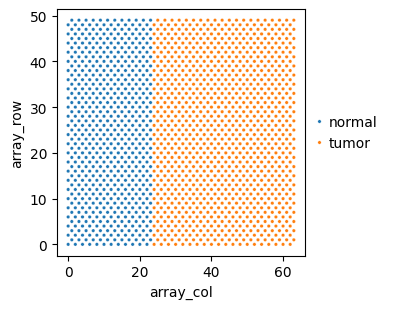

In [17]:
df = df_spatial.merge(cell_anno, left_on = 'barcode', right_on = 'cell', how = 'inner')

default_palette = sns.color_palette()
custom_colors = {
    'out_tissue': default_palette[7],  # 'grey'  
    'normal': default_palette[0],      # 'blue'
    'tumor': default_palette[1]        # 'orange'
}

fig = plt.figure(figsize = (4, 3.2))
sns.scatterplot(
    data = df, x = 'array_col', y = 'array_row', 
    hue = 'clone', s = 6, palette = custom_colors
)
#plt.legend(loc = 'lower center', bbox_to_anchor = (0.46, 0.97), frameon = False, ncol = 2, handletextpad = -0.5)
plt.legend(loc = 'center left', bbox_to_anchor = (0.95, 0.5), frameon = False, handletextpad = -0.3)
plt.tight_layout()

plt.savefig(
    fname = os.path.join(spatial_dir, 'spatial.png'), 
    dpi = 300, 
    bbox_inches = 'tight'
)

In [18]:
fn = os.path.join(spatial_dir, 'tissue_positions_list.csv')
if os.path.exists(fn):
    print("Warning: spatial position file '%s' already exists!" % fn)
else:
    os.symlink(src = spatial_fn, dst = fn)